In [105]:
import pandas as pd
import numpy as np
import xarray as xr

In [106]:
naq_grid = np.fromfile(f'D:/workdata/38_2016-2020naqpms/wrfd01.dat',dtype= '>f4')
naq_grid = naq_grid.reshape((84,180,360))
naq_tap_heiz = naq_grid[60:80,126,126]
naq_uta_heiz = naq_grid[60:80,129,246]

In [107]:
#利用sys模块，获取脚本传入的参数
ct = xr.open_dataset(r'D:/workdata/42_10yr_naqpms/CT2022.molefrac_glb3x2_2018-01-01.nc',mode='r')

In [108]:
ct_tap_heiz = ct['gph'][0,:,63,102]
ct_uta_heiz = ct['gph'][0,:,64,22]

In [109]:
col_name_naq = ['time', 'col01', 'col02','col03','col04','col05','col06','col07','col08','col09','col10','col11','col12','col13','col14','col15','col16','col17','col18','col19','col20',]
col_name_ct  = ['time', 'col01', 'col02','col03','col04','col05','col06','col07','col08','col09','col10','col11','col12','col13','col14','col15','col16','col17','col18','col19','col20',\
                'col21', 'col22','col23','col24','col25','col26','col27','col28','col29','col30','col31','col32','col33','col34']
tap_conc_naq_df = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\tap_conc_naq_hour.csv',header=None, names=col_name_naq)
tap_conc_ct_df  = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\tap_station_conc_ct_3hour.csv',header=None, names=col_name_ct)
uta_conc_naq_df = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\uta_conc_naq_hour.csv',header=None, names=col_name_naq)
uta_conc_ct_df  = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\uta_station_conc_ct_3hour.csv',header=None, names=col_name_ct)

In [110]:
# 确保时间列的格式正确，这里假设时间列名称为 'Station'，需要转换为 datetime 格式
tap_conc_naq_df['time'] = pd.to_datetime(tap_conc_naq_df['time'], format='%Y%m%d%H')
tap_conc_ct_df['time'] = pd.to_datetime(tap_conc_ct_df['time'], format='%Y%m%d%H')
uta_conc_naq_df['time'] = pd.to_datetime(uta_conc_naq_df['time'], format='%Y%m%d%H')
uta_conc_ct_df['time'] = pd.to_datetime(uta_conc_ct_df['time'], format='%Y%m%d%H')
# 按月份进行分割并存储到字典中
#tap_conc_naq_monthly_data = {str(month): data for month, data in tap_conc_naq_df.groupby(tap_conc_naq_df['time'].dt.to_period('M'))}
#tap_conc_ct_monthly_data = {str(month): data for month, data in tap_conc_ct_df.groupby(tap_conc_ct_df['time'].dt.to_period('M'))}
#uta_conc_naq_monthly_data = {str(month): data for month, data in uta_conc_naq_df.groupby(uta_conc_naq_df['time'].dt.to_period('M'))}
#uta_conc_ct_monthly_data = {str(month): data for month, data in uta_conc_ct_df.groupby(uta_conc_ct_df['time'].dt.to_period('M'))}

In [111]:
def gethour(df):
    df.columns = ['time'] + [f'col{i+1}' for i in range(len(df.columns)-1)]

    # 将时间列转换为日期时间格式
    df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H')

    # 提取小时作为新的列
    df['hour'] = df['time'].dt.hour

    # 按小时分组并计算每个小时的均值
    hourly_avg = df.groupby('hour').mean()
    return hourly_avg

In [112]:
tap_conc_naq_hour = gethour(tap_conc_naq_df)
tap_conc_ct_hour = gethour(tap_conc_ct_df)
uta_conc_naq_hour = gethour(uta_conc_naq_df)
uta_conc_ct_hour = gethour(uta_conc_ct_df)

In [113]:
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter

In [114]:
#横轴
#xx3h = np.arange(6*24,99*24,3)+1  #ct
xxn = np.arange(12)+1 #naq,obs
xxnh = np.arange(20)+1 #naq,obs
xxch = np.arange(30)+1 

In [115]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker



In [116]:
import matplotlib.patches as mpatches  # 导入 matplotlib.patches 模块

In [117]:
ct_tap_heiz_mid  = (ct_tap_heiz.values[:-1] + ct_tap_heiz.values[1:]) / 2
ct_uta_heiz_mid  = (ct_uta_heiz.values[:-1] + ct_uta_heiz.values[1:]) / 2

In [118]:
variables = ('00','01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23')
xv = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
variables = ('00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23')
xv2 = np.array([1.5, 4.5, 7.5, 10.5, 13.5, 16.5, 19.5, 22.5])

In [119]:
import numpy as np
from scipy.interpolate import interp1d

# 生成共同时间轴（覆盖两组时间范围）
new_time = np.linspace(0, 
                      24, 
                      72)  # 示例使用50个时间点

# 初始化插值后的数据容器
naq_time_interp_tap = np.zeros((len(new_time), 20))
ct_time_interp_tap = np.zeros((len(new_time), 34))

# 对每个高度层进行时间维度插值
for h_idx in range(20):
    f = interp1d(xv, tap_conc_naq_hour.values[:, h_idx], kind='linear', fill_value='extrapolate')
    naq_time_interp_tap[:, h_idx] = f(new_time)

for h_idx in range(34):
    f = interp1d(xv2, tap_conc_ct_hour.values[:, h_idx], kind='linear', fill_value='extrapolate')
    ct_time_interp_tap[:, h_idx] = f(new_time)

In [120]:
# 确定共同高度范围
h_min = max(naq_tap_heiz.min(), ct_tap_heiz_mid.min())
h_max = min(naq_tap_heiz.max(), ct_tap_heiz_mid.max())
h_new_tap = np.linspace(h_min, h_max, 100)  # 新高度轴

# 初始化最终插值结果
naq_final_tap = np.zeros((len(new_time), len(h_new_tap)))
ct_final_tap = np.zeros((len(new_time), len(h_new_tap)))

# 对每个时间点进行高度插值
for t_idx in range(len(new_time)):
    # 插值数据集A
    f1 = interp1d(naq_tap_heiz, naq_time_interp_tap[t_idx, :], 
                 kind='linear', bounds_error=False, fill_value=np.nan)
    naq_final_tap[t_idx, :] = f1(h_new_tap)
    
    # 插值数据集B
    f2 = interp1d(ct_tap_heiz_mid, ct_time_interp_tap[t_idx, :], 
                 kind='linear', bounds_error=False, fill_value=np.nan)
    ct_final_tap[t_idx, :] = f2(h_new_tap)

In [121]:
import numpy as np
from scipy.interpolate import interp1d

# 生成共同时间轴（覆盖两组时间范围）
new_time = np.linspace(0, 
                      24, 
                      72)  # 示例使用50个时间点

# 初始化插值后的数据容器
naq_time_interp_uta = np.zeros((len(new_time), 20))
ct_time_interp_uta = np.zeros((len(new_time), 34))

# 对每个高度层进行时间维度插值
for h_idx in range(20):
    f = interp1d(xv, uta_conc_naq_hour.values[:, h_idx], kind='linear', fill_value='extrapolate')
    naq_time_interp_uta[:, h_idx] = f(new_time)

for h_idx in range(34):
    f = interp1d(xv2, uta_conc_ct_hour.values[:, h_idx], kind='linear', fill_value='extrapolate')
    ct_time_interp_uta[:, h_idx] = f(new_time)

In [122]:
# 确定共同高度范围
h_min = max(naq_uta_heiz.min(), ct_uta_heiz_mid.min())
h_max = min(naq_uta_heiz.max(), ct_uta_heiz_mid.max())
h_new_uta = np.linspace(h_min, h_max, 100)  # 新高度轴

# 初始化最终插值结果
naq_final_uta = np.zeros((len(new_time), len(h_new_uta)))
ct_final_uta = np.zeros((len(new_time), len(h_new_uta)))

# 对每个时间点进行高度插值
for t_idx in range(len(new_time)):
    # 插值数据集A
    f1 = interp1d(naq_uta_heiz, naq_time_interp_uta[t_idx, :], 
                 kind='linear', bounds_error=False, fill_value=np.nan)
    naq_final_uta[t_idx, :] = f1(h_new_uta)
    
    # 插值数据集B
    f2 = interp1d(ct_uta_heiz_mid, ct_time_interp_uta[t_idx, :], 
                 kind='linear', bounds_error=False, fill_value=np.nan)
    ct_final_uta[t_idx, :] = f2(h_new_uta)

In [126]:
ct_final_tap_local = np.zeros((72,100))
naq_final_tap_local = np.zeros((72,100))

ct_final_tap_local[0:27,:] = ct_final_tap[45:,:]
ct_final_tap_local[27:,:] = ct_final_tap[:45,:]

naq_final_tap_local[0:27,:] = naq_final_tap[45:,:]
naq_final_tap_local[27:,:] = naq_final_tap[:45,:]

In [127]:
ct_final_uta_local = np.zeros((72,100))
naq_final_uta_local = np.zeros((72,100))

ct_final_uta_local[0:51,:] = ct_final_uta[21:,:]
ct_final_uta_local[51:,:] = ct_final_uta[:21,:]

naq_final_uta_local[0:51,:] = naq_final_uta[21:,:]
naq_final_uta_local[51:,:] = naq_final_uta[:21,:]

In [129]:
from matplotlib.colors import BoundaryNorm  # 新增导入
import matplotlib.colors as colors

In [151]:
#colorslist = ['#0024ff','#0089ff','#00eeff','#00ffaa','#85ff00','#dfff00','#ffa300','#ff6b00','#ff1100']
colorslist = ['#13457E','#2C76AC','#69A5C7','#AED0E1','#E4ECF3','#FFFFFF','#F9E8DE','#DB7C64','#DB7C64','#BB3A3C','#841925']
cmap = colors.LinearSegmentedColormap.from_list('mylist',colorslist,N=9*20)
cn = 2
zz = np.array([-30,-20,-10,-5,-1,1,5,10,20,30])
zz_tap=zz
aa = np.linspace(zz[0], zz[1], num=cn)
bb = np.linspace(zz[1], zz[2], num=cn)
cc = np.linspace(zz[2], zz[3], num=cn)
dd = np.linspace(zz[3], zz[4], num=cn)
ee = np.linspace(zz[4], zz[5], num=cn)
ff = np.linspace(zz[5], zz[6], num=cn)
gg = np.linspace(zz[6], zz[7], num=cn)
hh = np.linspace(zz[7], zz[8], num=cn)
ii = np.linspace(zz[8], zz[9], num=cn)
bounds_tap = concatenate((aa[:-1],bb[:-1],cc[:-1],dd[:-1],ee[:-1],ff[:-1],gg[:-1],hh[:-1],ii[:]),axis=0)
# change to ton
norm_tap = colors.BoundaryNorm(bounds_tap, cmap.N)
   # pcm = fig_ax1.pcolor(lon, lat,var,cmap=cmap,norm = norm,transform=ccrs.PlateCarree(),alpha=0.6)

In [ ]:
#colorslist = ['#0024ff','#0089ff','#00eeff','#00ffaa','#85ff00','#dfff00','#ffa300','#ff6b00','#ff1100']
colorslist = ['#13457E','#2C76AC','#69A5C7','#AED0E1','#E4ECF3','#FFFFFF','#F9E8DE','#DB7C64','#DB7C64','#BB3A3C','#841925']
cmap = colors.LinearSegmentedColormap.from_list('mylist',colorslist,N=9*20)
cn = 2
zz = np.array([-15,-10,-5,-2,-1,1,2,5,10,15])
zz_uta=zz
aa = np.linspace(zz[0], zz[1], num=cn)
bb = np.linspace(zz[1], zz[2], num=cn)
cc = np.linspace(zz[2], zz[3], num=cn)
dd = np.linspace(zz[3], zz[4], num=cn)
ee = np.linspace(zz[4], zz[5], num=cn)
ff = np.linspace(zz[5], zz[6], num=cn)
gg = np.linspace(zz[6], zz[7], num=cn)
hh = np.linspace(zz[7], zz[8], num=cn)
ii = np.linspace(zz[8], zz[9], num=cn)
bounds_uta = concatenate((aa[:-1],bb[:-1],cc[:-1],dd[:-1],ee[:-1],ff[:-1],gg[:-1],hh[:-1],ii[:]),axis=0)
# change to ton
norm_uta = colors.BoundaryNorm(bounds_uta, cmap.N)
   # pcm = fig_ax1.pcolor(lon, lat,var,cmap=cmap,norm = norm,transform=ccrs.PlateCarree(),alpha=0.6)

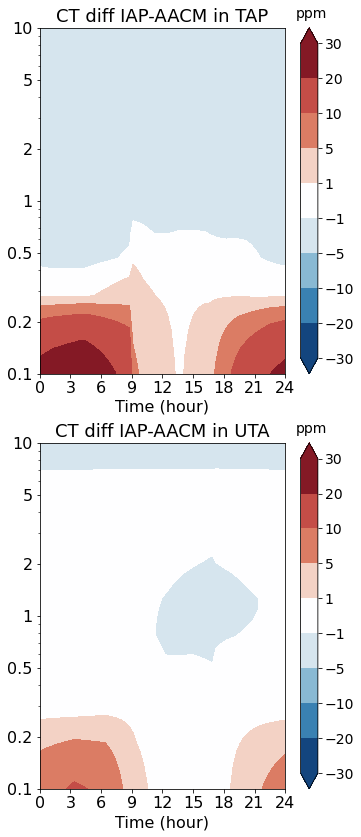

In [166]:
# 计算差值
diff_tap = ct_final_tap_local - naq_final_tap_local / 1000
diff_uta = ct_final_uta_local - naq_final_uta_local / 1000

# 为 TAP 设置独立的 vmin/vmax（对称）
abs_max_tap = np.nanmax(np.abs(diff_tap))
vmin_tap = -30
vmax_tap = 30

# 为 UTA 设置独立的 vmin/vmax（对称）
abs_max_uta = np.nanmax(np.abs(diff_uta))
vmin_uta = -30
vmax_uta = 30

# 创建子图
fig, ax = plt.subplots(2, 1, figsize=(5.5, 14))


# TAP 图
c0 = ax[0].contourf(
    new_time,
    h_new_tap/1000 - h_new_tap[0]/1000 + 0.1,
    diff_tap.T/1.1-2.5,
    cmap=cmap,
    norm=norm_tap,  # 使用BoundaryNorm
    levels=zz_tap, 
    extend='both' ,# 指定分界点
      # 扩展箭头显示超界值
)
ax[0].set_title('CT diff IAP-AACM in TAP', fontsize=18)
ax[0].set_xlabel('Time (hour)', fontsize=16)
#ax[0].set_ylabel('Altitude above ground (km)', fontsize=18)
ax[0].set_xticks(np.arange(0, 25, 3))
ax[0].set_yscale('log')
ax[0].set_ylim(0.1, 10)
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
c0_cb = fig.colorbar(c0, ax=ax[0], orientation='vertical', extend='both')
c0_cb.ax.tick_params(labelsize=14)
ax[0].text(25, 11.4, 'ppm', fontsize=14)

# UTA 图
c1 = ax[1].contourf(
    new_time,
    h_new_uta/1000 - h_new_uta[0]/1000 + 0.1,
    diff_uta.T-1,
    cmap=cmap,
    norm=norm_tap,  # 使用BoundaryNorm
    levels=zz_tap, 
       extend='both' , # 指定分界点  # 扩展箭头显示超界值
)
ax[1].set_title('CT diff IAP-AACM in UTA', fontsize=18)
ax[1].set_xlabel('Time (hour)', fontsize=16)
ax[1].set_xticks(np.arange(0, 25, 3))
ax[1].set_yscale('log')
ax[1].set_ylim(0.1, 10)
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
c1_cb = fig.colorbar(c1, ax=ax[1], orientation='vertical', extend='both')
c1_cb.ax.tick_params(labelsize=14)
ax[1].text(25, 11.4, 'ppm', fontsize=14)

ax[0].tick_params(axis='x', labelsize=16)
ax[0].tick_params(axis='y', labelsize=14)
ax[1].tick_params(axis='x', labelsize=16)
ax[1].tick_params(axis='y', labelsize=14)

ax[0].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[0].set_yscale('log')
ax[1].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[1].set_yscale('log')


yticks_positions = [0.1, 0.2, 0.5, 1, 2, 5,10]
yticks_labels = ['0.1', '0.2', '0.5', '1', '2', '5','10' ]
ax[0].set_yticks(yticks_positions)
ax[0].set_yticklabels(yticks_labels, fontsize=16)
ax[1].set_yticks(yticks_positions)
ax[1].set_yticklabels(yticks_labels, fontsize=16)


# 图像分辨率
plt.rcParams['savefig.dpi'] = 500

plt.savefig(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\论文用图v5\iapaacm_tap_uta.contourf.r5.diff.hour.v3.png', bbox_inches='tight')

